# R-KV Token Dropping Example with LMCache SDK
---

Long prompts create large KV caches that eat up GPU memory and limit how many
requests fit in a batch, and a smaller batch means lower decode throughput.
Token dropping shrinks each request's KV cache (in this example by half), so more
requests fits in a batch. This notebook shows improvement in decode
throughput by using LMCache's SDK API that enables ML engineers get
a requests' KV, do optimizations such as token dropping, and put it back to use
during LLM serving.

This notebook is a short demonstration in GPU with smaller capacity:
* Google Colab GPU T4: 15GB GPU memory, 12GB RAM, shared memory capacity 5.6GB
* Shorter workload: 10 prompts @ ~1024 input tokens, 256 output tokens
* LMCache L1 size: 3GB
* vLLM GPU memory utilization: 0.35

At this small scale expect roughly **2.0x decode throughput at unchanged
accuracy**. The larger speedups quoted upstream come from bigger GPUs and longer
prompts, where the freed KV space buys a proportionally bigger batch.

The amount of workload, L1 size, and GPU memory utilization should be adjusted
altogether to fit in the constrained space to emulate condition where dropping
tokens (e.g. by half) increases the batch size (e.g. by 2x).

For larger scale demonstration and experiment, please refer to
[LMCache SDK example](https://github.com/LMCache/LMCache/tree/dev/examples/token_dropping).

## What this notebook does?

There is one manual step in the middle: stop at the "Press Restart now"
markdown cell, restart the kernel, then carry on. Because of that, "Run all"
will not work.

**0. Prepare environment, vLLM, and LMCache**

* Google Colab GPU T4 by default is shipped with cu128. vLLM does not ship
  precompiled binary using cu128, hence we need to upgrade to cu130 to avoid
  full compilation.
* This notebook installs vLLM via vLLM's PyPI release on version 0.23.0 and
  LMCache from the nightly wheel index (query tensor transfer is not in a
  stable release yet).

**1. Start LMCache server**

To use shared memory, specify the `--shm-name` and `--no-l1-use-lazy`.
To enable query tensor transfer, we pass `--enable transfer_query`.

Below is an example, but please DO NOT run it in this notebook.

```sh
lmcache server \
    --l1-size-gb 3 \
    --eviction-policy LRU \
    --chunk-size 256 \
    --port 6555 \
    --http-port 8081 \
    --shm-name lmcache_sdk \
    --no-l1-use-lazy \
    --enable transfer_query \
    --max-workers 4 \
    --eviction-trigger-watermark 0.98 \
    --supported-transfer-mode auto
```

Although Google Colab has 12GB RAM (11GB available), LMCache on Google Colab
throws error when used entirely.
After starting LMCache, it will wait until LMCache server is ready.

**2. Start vLLM once LMCache server is ready**

We pass --no-enable-prefix-caching to disable vLLM's built-in prefix caching.
This ensures the prefilled KV cache is always served from LMCache rather than
vLLM, so the decoding throughput improvement can be attributed entirely to the
tokens dropped through LMCache.

Below is an example, but please DO NOT run it in this notebook.

```sh
VLLM_USE_FLASHINFER_SAMPLER=0 vllm serve Qwen/Qwen3-1.7B \
    --port 8000 \
    --served-model-name Qwen/Qwen3-1.7B \
    --no-enable-prefix-caching \
    --enforce-eager \
    --gpu-memory-utilization 0.35 \
    --kv-transfer-config '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true,"lmcache.mp.heartbeat_interval":30}}' \
    --trust-remote-code \
    --return-tokens-as-token-ids \
    --max-model-len 2048 \
    --max-num-batched-tokens 12288 \
    --attention-backend TRITON_ATTN
```

To enable query tensor transfer, pass
`"lmcache.mp.transfer_intermediate_tensors":true` as an additional argument
to `--kv-transfer-config`. To adjust the QRingBuffer capacity, which holds
the query tensor temporarily before storing in L1, add `"lmcache.q.ring_depth"`
to the same config; it defaults to 2 (2 means the QRingBuffer can hold the
query tensors of 2 forward passes).

`VLLM_USE_FLASHINFER_SAMPLER=0` and `--attention-backend TRITON_ATTN` are there
for the T4: FlashInfer has no sm75 sampling kernel, so vLLM otherwise dies
during warmup with a confusing `Engine core initialization failed`. Both are
harmless on newer GPUs.

**3. Prepares the SDK and Evaluation**

The notebook then pulls the prepared short dataset, taken from LongBench-V2,
filtering 10 requests with length closest to 1024 tokens and unique contexts.

SDK contexts for both KV and Q are then made, and used for 2x experiments:
1. Baseline (no dropping).
2. R-KV token dropping.

After the SDK contexts are done being used, the context is then closed and both
vLLM and LMCache process are killed.

## **Note:** Please run the cells one at a time rather than using **Run all**, because you will need to restart the session midway through the notebook.


## 0. Prepare environment, vLLM, and LMCache

In [ ]:
%%bash

nvidia-smi
free -h

# Informational only: nvcc is not needed at runtime (vLLM ships precompiled
# kernels) and is often not on PATH even when the toolkit is installed.
if command -v nvcc >/dev/null; then
    nvcc --version
else
    ls -d /usr/local/cuda*/bin/nvcc 2>/dev/null || echo "nvcc: not on PATH (harmless)"
fi


Wed Aug  5 03:48:29 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   49C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
import os
import sys

os.environ["LMCACHE_DIR"] = "/content/LMCache"
os.environ["HF_TOKEN"] = ""  # paste HuggingFace token here

# The install cells below target this interpreter. Taking it from the running
# kernel keeps the notebook portable: on Colab it is /usr/bin/python3, in a
# local venv it is that venv's python.
os.environ["VENV_PY"] = sys.executable
print("installing into:", sys.executable)

installing into: /usr/bin/python3


In [ ]:
%%bash
set -eox pipefail

# $VENV_PY comes from the cell above. `--system` only relaxes uv's "must be a
# virtualenv" rule, which is what Colab needs; it is ignored when $VENV_PY
# already points at a venv.
UV="uv pip install --python $VENV_PY --system"

# Colab-only step: that image ships cu128 and vLLM publishes no cu128 wheels.
# Most other hosts have no system CUDA toolkit and do not need one -- the torch
# and vLLM wheels bundle their own CUDA runtime. Export INSTALL_CUDA_TOOLKIT=1
# first if you really want it (several GB).
if [ "${INSTALL_CUDA_TOOLKIT:-0}" = "1" ]; then
    sudo -n apt-get -y install cuda-toolkit-13-0
fi

pip install -q uv
uv pip uninstall --python "$VENV_PY" --system -y vllm lmcache torch >/dev/null 2>&1 || true

# The only point of this step is to seed the +cu130 builds from the PyTorch
# index before vLLM is installed. The versions MUST match what vllm==0.23.0
# pins, otherwise the next cell downgrades the whole stack again (and leaves
# torchaudio behind at a mismatched version). Verify with:
#   echo 'vllm==0.23.0' | uv pip compile - | grep -E '^(torch|triton|numpy)'
$UV --force-reinstall \
    torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 \
    --index-url https://download.pytorch.org/whl/cu130
"$VENV_PY" -c "import torch; print('torch:', torch.__version__, '| cuda:', torch.version.cuda)"


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 22.4/22.4 MB 71.3 MB/s eta 0:00:00
torch: 2.11.0+cu130 | cuda: 13.0


+ UV='uv pip install --python /usr/bin/python3 --system'
+ '[' 0 = 1 ']'
+ pip install -q uv
+ uv pip uninstall --python /usr/bin/python3 --system -y vllm lmcache torch
+ uv pip install --python /usr/bin/python3 --system --force-reinstall torch==2.11.0 torchvision==0.26.0 torchaudio==2.11.0 --index-url https://download.pytorch.org/whl/cu130
Using Python 3.12.13 environment at: /usr
Resolved 33 packages in 3.86s
Prepared 33 packages in 1m 03s
Uninstalled 17 packages in 253ms
Installed 33 packages in 331ms
 - cuda-bindings==12.9.7
 + cuda-bindings==13.0.3
 - cuda-pathfinder==1.5.6
 + cuda-pathfinder==1.2.2
 - cuda-toolkit==12.8.1
 + cuda-toolkit==13.0.2
 - filelock==3.29.7
 + filelock==3.29.0
 - fsspec==2025.3.0
 + fsspec==2026.4.0
 ~ jinja2==3.1.6
 ~ markupsafe==3.0.3
 ~ mpmath==1.3.0
 ~ networkx==3.6.1
 - numpy==2.0.2
 + numpy==2.4.4
 + nvidia-cublas==13.1.0.3
 + nvidia-cuda-cupti==13.0.85
 + nvidia-cuda-nvrtc==13.0.88
 + nvidia-cuda-runtime==13.0.96
 + nvidia-cudnn-cu13==9.19.0.56
 + 

In [ ]:
%%bash
set -exo pipefail
export MAX_JOBS="$(nproc)"
uv pip install --python "$VENV_PY" --system --force-reinstall vllm==0.23.0


++ nproc
+ export MAX_JOBS=2
+ MAX_JOBS=2
+ uv pip install --python /usr/bin/python3 --system --force-reinstall vllm==0.23.0
Using Python 3.12.13 environment at: /usr
Resolved 193 packages in 1.81s
Prepared 193 packages in 1m 55s
Uninstalled 124 packages in 1.17s
Installed 193 packages in 1.99s
 ~ aiohappyeyeballs==2.7.1
 - aiohttp==3.14.1
 + aiohttp==3.14.3
 ~ aiosignal==1.4.0
 - annotated-doc==0.0.4
 + annotated-doc==0.0.5
 - annotated-types==0.7.0
 + annotated-types==0.8.0
 + anthropic==0.120.2
 ~ anyio==4.14.2
 + apache-tvm-ffi==0.1.9
 + astor==0.8.1
 ~ attrs==26.1.0
 + blake3==1.0.9
 - cachetools==6.2.6
 + cachetools==7.1.7
 + cbor2==6.1.4
 - certifi==2026.6.17
 + certifi==2026.7.22
 - cffi==2.1.0
 + cffi==2.1.1
 ~ charset-normalizer==3.4.9
 ~ click==8.4.2
 ~ cloudpickle==3.1.2
 + compressed-tensors==0.17.0
 - cryptography==49.0.0
 + cryptography==50.0.0
 - cuda-bindings==13.0.3
 + cuda-bindings==13.3.1
 - cuda-core==0.3.2
 + cuda-core==1.0.1
 - cuda-pathfinder==1.2.2
 + cuda-path

In [ ]:
%%bash
python -c "import vllm; print(vllm.__file__, vllm.__version__)"
python -c "import torch; print('torch CUDA build:', torch.version.cuda)"
vllm --version

/usr/local/lib/python3.12/dist-packages/vllm/__init__.py 0.23.0
torch CUDA build: 13.0
0.23.0


In [ ]:
%%bash
set -euo pipefail

cd /content
[ -d LMCache ] || git clone --depth 1 https://github.com/LMCache/LMCache.git
echo "  ✓ LMCache at $LMCACHE_DIR"

DIFF="/content/LMCache/examples/token_dropping/vllm-export-intermediate-tensors.diff"

[ -f "$DIFF" ] || { echo "!! diff not found at: $DIFF"; exit 1; }

SITE=$(python -c "import vllm, os; print(os.path.dirname(os.path.dirname(vllm.__file__)))")
cd "$SITE"
if patch -p1 --forward --dry-run < "$DIFF" >/dev/null 2>&1; then
    patch -p1 --forward < "$DIFF" >/dev/null && echo "  ✓ patch applied to $SITE/vllm"
elif patch -p1 -R --dry-run < "$DIFF" >/dev/null 2>&1; then
    echo "  ✓ patch already present (skipping)"
else
    echo "  !! PATCH FAILED: this vLLM release differs from the diff's base."
    exit 1
fi

  ✓ LMCache at /content/LMCache
  ✓ patch applied to /usr/local/lib/python3.12/dist-packages/vllm


Cloning into 'LMCache'...


In [ ]:
import os
import subprocess
import sys

os.environ["NUMPY_VERSION"] = subprocess.run(
    [sys.executable, "-c", "import numpy; print(numpy.__version__)"],
    capture_output=True,
    text=True,
    check=True,
).stdout.strip()
print("numpy to pin:", os.environ["NUMPY_VERSION"])

numpy to pin: 2.3.5


In [ ]:
%%bash
set -eox pipefail
UV="uv pip install --python $VENV_PY --system"

$UV lmcache --pre \
    --extra-index-url https://download.pytorch.org/whl/cu128 \
    --find-links https://github.com/LMCache/LMCache/releases/expanded_assets/nightly \
    --index-strategy unsafe-best-match
$UV "opentelemetry-exporter-prometheus==0.65b0"

# lmcache's resolution can bump numpy past what vLLM pins, so restore it.
$UV --force-reinstall "numpy==${NUMPY_VERSION}"
echo "  ✓ lmcache installed"


  ✓ lmcache installed


+ UV='uv pip install --python /usr/bin/python3 --system'
+ uv pip install --python /usr/bin/python3 --system lmcache --pre --extra-index-url https://download.pytorch.org/whl/cu128 --find-links https://github.com/LMCache/LMCache/releases/expanded_assets/nightly --index-strategy unsafe-best-match
Using Python 3.12.13 environment at: /usr
Resolved 124 packages in 4.98s
Prepared 24 packages in 2.90s
Uninstalled 13 packages in 39ms
Installed 24 packages in 348ms
 + aiofile==3.12.3
 + awscrt==0.36.1
 + caio==0.12.2
 + cufile-python==0.2.0
 + cupy-cuda13x==14.1.1
 + google-cloud-bigtable==2.41.0
 - grpcio-status==1.71.2
 + grpcio-status==1.83.0
 - importlib-metadata==9.0.0
 + importlib-metadata==8.7.1
 + lmcache==0.5.3rc2
 - numpy==2.3.5
 + numpy==2.2.6
 - opentelemetry-api==1.44.0
 + opentelemetry-api==1.40.0
 - opentelemetry-exporter-otlp==1.44.0
 + opentelemetry-exporter-otlp==1.40.0
 - opentelemetry-exporter-otlp-proto-common==1.44.0
 + opentelemetry-exporter-otlp-proto-common==1.40.0
 - 

In [ ]:
import os
import sys
import subprocess

print("LMCACHE_DIR (env):", os.environ.get("LMCACHE_DIR"))
print("python:", sys.executable)
out = subprocess.run(["pip", "show", "lmcache"], capture_output=True, text=True).stdout
print(out or "not successfully installed")

LMCACHE_DIR (env): /content/LMCache
python: /usr/bin/python3
Name: lmcache
Version: 0.5.3rc2
Summary: A LLM serving engine extension to reduce TTFT and increase throughput, especially under long-context scenarios.
Home-page: https://docs.lmcache.ai
Author: 
Author-email: LMCache Team <lmcacheteam@gmail.com>
License: 
Location: /usr/local/lib/python3.12/dist-packages
Requires: aiofile, aiofiles, aiohttp, awscrt, blake3, cachetools, cryptography, cufile-python, cupy-cuda13x, fastapi, google-api-core, google-cloud-bigtable, httptools, httpx, huggingface_hub, msgspec, numba, numpy, nvtx, opentelemetry-api, opentelemetry-exporter-otlp, opentelemetry-exporter-prometheus, opentelemetry-sdk, prometheus_client, psutil, py-cpuinfo, pytest, pyyaml, pyzmq, redis, safetensors, setuptools, setuptools_scm, sortedcontainers, torch, transformers, uvicorn
Required-by: 



In [ ]:
!python -c "import lmcache; print(lmcache.__file__, lmcache.__version__)"

[2026-08-05 03:55:01,090] LMCache INFO: torch_dev=<module 'torch.cuda' from '/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (_device_detect.py:143:lmcache.v1.platform._device_detect)
[2026-08-05 03:55:01,100] LMCache WARNING: lmcache.c_ops compiled extension not found; CudaDeviceOps stays on the torch baseline for all ops. (device_ops.py:34:lmcache.v1.platform.cuda.device_ops)
/usr/local/lib/python3.12/dist-packages/lmcache/__init__.py 0.5.3rc2


## Press "Runtime -> Restart session" now

The cells above replaced packages that this kernel may already have loaded, so
restart the kernel before going further.

**Restart here, not after the servers start.** The launcher below spawns
LMCache and vLLM as background processes. `start_new_session=True` detaches
them on Colab, but VS Code's "Restart Kernel" terminates the kernel's entire
process tree, which kills both servers and makes every SDK cell below fail with
`Connection refused ... localhost:8081`.

## 1 and 2. Run LMCache and vLLM


In [ ]:
%%bash
hf download Qwen/Qwen3-1.7B


✓ Downloaded
  path: /root/.cache/huggingface/hub/models--Qwen--Qwen3-1.7B/snapshots/70d244cc86ccca08cf5af4e1e306ecf908b1ad5e


Fetching 12 files: 100%|██████████| 12/12 [00:35<00:00,  2.96s/it]


In [ ]:
%%bash
df -h /dev/shm
free -h

# A leftover pool from a crashed run must be removed, otherwise the new
# LMCache server attaches to a segment with the wrong size. On a clean boot
# there is nothing to list, which is the expected case.
ls -la /dev/shm/lmcache* 2>/dev/null || echo "no stale lmcache pool (good)"
rm -f /dev/shm/lmcache_l1_pool_lmcache_sdk


Filesystem      Size  Used Avail Use% Mounted on
shm             5.7G     0  5.7G   0% /dev/shm
               total        used        free      shared  buff/cache   available
Mem:            12Gi       2.3Gi       1.1Gi       2.0Mi       9.2Gi        10Gi
Swap:             0B          0B          0B
no stale lmcache pool (good)


In [ ]:
# The bracket keeps pgrep from matching the shell that runs pgrep itself:
# the regex "[l]mcache server" matches "lmcache server" but not this line.
!pgrep -af "[l]mcache server" || echo "LMCache: NOT running"
!pgrep -af "[v]llm serve"     || echo "vLLM:    NOT running"

LMCache: NOT running
vLLM:    NOT running


In [ ]:
import os
import time
import subprocess
import urllib.request

LOG = "/content/logs"
os.makedirs(LOG, exist_ok=True)
lmc_log, vllm_log = f"{LOG}/lmcache.log", f"{LOG}/vllm.log"


def launch(cmd, log_path, extra_env=None):
    f = open(log_path, "w")
    env = {**os.environ, **(extra_env or {})}
    return subprocess.Popen(
        cmd, stdout=f, stderr=subprocess.STDOUT, start_new_session=True, env=env
    )


def wait_ready(url, name, proc, log_path, timeout):
    t0 = time.time()
    while time.time() - t0 < timeout:
        if proc.poll() is not None:
            print(f"✗ {name} exited early (code {proc.returncode}). Last log lines:\n")
            print(open(log_path).read()[-3000:])
            return False
        try:
            with urllib.request.urlopen(url, timeout=5) as r:
                if r.status == 200:
                    print(f"✓ {name} ready in {int(time.time() - t0)}s")
                    return True
        except Exception:
            pass
        el = int(time.time() - t0)
        if el and el % 15 == 0:
            last = (open(log_path).read().strip().splitlines() or [""])[-1]
            print(f"  … waiting for {name} ({el}s)  | {last[-100:]}")
        time.sleep(3)
    print(f"✗ {name} not ready after {timeout}s. Last log lines:\n")
    print(open(log_path).read()[-3000:])
    return False


# 1) LMCache server (background) → wait until up
lmc = launch(
    [
        "lmcache",
        "server",
        "--supported-transfer-mode",
        "auto",
        "--l1-size-gb",
        "3",
        "--eviction-policy",
        "LRU",
        "--chunk-size",
        "256",
        "--port",
        "6555",
        "--http-port",
        "8081",
        "--shm-name",
        "lmcache_sdk",
        "--no-l1-use-lazy",
        "--enable",
        "transfer_query",
        "--max-workers",
        "4",
        "--eviction-trigger-watermark",
        "0.98",
    ],
    lmc_log,
)
print(f"LMCache PID {lmc.pid} → {lmc_log}")

if wait_ready(
    "http://localhost:8081/healthcheck", "LMCache", lmc, lmc_log, timeout=180
):
    # 2) vLLM (background) → wait until up
    vllm = launch(
        [
            "vllm",
            "serve",
            "Qwen/Qwen3-1.7B",
            "--port",
            "8000",
            "--served-model-name",
            "Qwen/Qwen3-1.7B",
            "--no-enable-prefix-caching",
            "--enforce-eager",
            "--gpu-memory-utilization",
            "0.35",
            "--kv-transfer-config",
            '{"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true,"lmcache.mp.heartbeat_interval":30}}',
            "--trust-remote-code",
            "--return-tokens-as-token-ids",
            "--max-model-len",
            "2048",
            "--max-num-batched-tokens",
            "12288",
            "--attention-backend",
            "TRITON_ATTN",
        ],
        vllm_log,
        # FlashInfer's top-k/top-p sampling kernels are not built for sm75 (T4),
        # so vLLM dies during warmup inside flashinfer_sample(). Fall back to
        # the PyTorch sampler. Harmless on newer GPUs.
        extra_env={"VLLM_USE_FLASHINFER_SAMPLER": "0"},
    )
    print(f"vLLM PID {vllm.pid} → {vllm_log}")
    wait_ready("http://localhost:8000/v1/models", "vLLM", vllm, vllm_log, timeout=1800)

LMCache PID 3369 → /content/logs/lmcache.log
  … waiting for LMCache (15s)  | aPinMemoryBackend: using torch cudart (pin_memory.py:89:lmcache.v1.platform.cuda.pin_memory)
✓ LMCache ready in 18s
vLLM PID 3490 → /content/logs/vllm.log
  … waiting for vLLM (15s)  | 
  … waiting for vLLM (30s)  | ted requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
  … waiting for vLLM (45s)  | ted requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
  … waiting for vLLM (60s)  | ver pid=3490) INFO 08-05 03:57:07 [compilation.py:321] Enabled custom fusions: norm_quant, act_quant
  … waiting for vLLM (75s)  | ver pid=3490) INFO 08-05 03:57:07 [compilation.py:321] Enabled custom fusions: norm_quant, act_quant
  … waiting for vLLM (90s)  | Loading safetensors checkpoint shards:   0% Completed | 0/2 [00:00<?, ?it/s]
  … waiting for vLLM (105s)  | utils.py:408] ImportError: libnvrtc.so.13: cannot open shared object file:

In [ ]:
!pgrep -af "[l]mcache server" || echo "LMCache: NOT running"
!pgrep -af "[v]llm serve"     || echo "vLLM:    NOT running"

3369 /usr/bin/python3 /usr/local/bin/lmcache server --l1-size-gb 3 --eviction-policy LRU --chunk-size 256 --port 6555 --http-port 8081 --shm-name lmcache_sdk --no-l1-use-lazy --enable transfer_query --max-workers 4 --eviction-trigger-watermark 0.98
3490 /usr/bin/python3 /usr/local/bin/vllm serve Qwen/Qwen3-1.7B --port 8000 --served-model-name Qwen/Qwen3-1.7B --no-enable-prefix-caching --enforce-eager --gpu-memory-utilization 0.35 --kv-transfer-config {"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true,"lmcache.mp.heartbeat_interval":30}} --trust-remote-code --return-tokens-as-token-ids --max-model-len 2048 --max-num-batched-tokens 12288 --attention-backend TRITON_ATTN


## Do **not** restart here

The kernel was already restarted further up, before the servers were launched.
Restarting now would take LMCache and vLLM down with it (VS Code kills the
kernel's whole process tree), and every cell below would fail with
`Connection refused ... localhost:8081`.


## 3. Prepare SDK and Evaluation

In [ ]:
%%bash

pwd && cd /content/LMCache/examples/token_dropping && pwd

/content
/content/LMCache/examples/token_dropping


In [ ]:
# ruff: noqa: E402

# Standard
from datasets import load_dataset
import json
import math
import matplotlib.pyplot as plt
import sys
from transformers import AutoTokenizer, AutoConfig

NB_DIR = "/content/LMCache/examples/token_dropping"
if NB_DIR not in sys.path:
    sys.path.insert(0, NB_DIR)

# Third Party
import torch
import torch.nn.functional as F

# First Party
from lmcache.logging import init_logger
import lmcache.sdk as lmc_sdk
from lmcache.banner import print_banner_once
from utils import (
    rerotate_k_cache,
    make_post_completion,
    score_answers,
)

print_banner_once(sys.stdout)
logger = init_logger(__name__)

[2026-08-05 03:59:01,382] LMCache INFO: torch_dev=<module 'torch.cuda' from '/usr/local/lib/python3.12/dist-packages/torch/cuda/__init__.py'>, torch_device_type=cuda (_device_detect.py:143:lmcache.v1.platform._device_detect)
[2026-08-05 03:59:01,387] LMCache WARNING: lmcache.c_ops compiled extension not found; CudaDeviceOps stays on the torch baseline for all ops. (device_ops.py:34:lmcache.v1.platform.cuda.device_ops)
[2026-08-05 03:59:01,504] LMCache INFO: multi_layer_block_kv_transfer mode: tensor (base.py:94:lmcache.v1.multiprocess.transfer_context.base)



 _     __  __    ____           _          
| |   |  \/  |  / ___|__ _  ___| |__   ___      LMCache v0.5.3rc2 (g6f53912b)
| |   | |\/| | | |   / _` |/ __| '_ \ / _ \     Website:  https://lmcache.ai/
| |___| |  | | | |__| (_| | (__| | | |  __/     Recipes:  https://docs.lmcache.ai/recipes
|_____|_|  |_|  \____\__,_|\___|_| |_|\___|     LinkedIn: https://www.linkedin.com/company/lmcache-lab
Set LMCACHE_DISABLE_BANNER=1 to hide this banner.



## Setting up hyperparameters

In [ ]:
model_name = "Qwen/Qwen3-1.7B"
vllm_url = "http://localhost:8000"
lmcache_url = "http://localhost:8081"
lmcache_mq_url = "tcp://localhost:6555"
chunk_size = 256
max_tokens = 256
temperature = 0.0  # greedy decode so generated answers are deterministic and scorable
timeout = 60  # timeout for context retrieval (seconds)
trust_remote_code = True

## Configuring the model and LMCache endpoint

In [ ]:
tokenizer = AutoTokenizer.from_pretrained(
    model_name, trust_remote_code=trust_remote_code
)
config = AutoConfig.from_pretrained(model_name, trust_remote_code=trust_remote_code)
work_device = torch.device("cpu")
post_completion = make_post_completion(vllm_url, model_name, timeout)
ctx = lmc_sdk.kvcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)
qctx = lmc_sdk.qcache.connect(
    url=lmcache_mq_url,
    http_url=lmcache_url,
    model_name=model_name,
    timeout=timeout,
)

[2026-08-05 03:59:13,653] LMCache INFO: Initialized LMCacheSDKContext with instance_id=2017876365172282408, model_name=Qwen/Qwen3-1.7B, chunk_size=256, shm_name=lmcache_l1_pool_lmcache_sdk, kind=LMCacheSDKCacheKind.KV (context.py:122:lmcache.sdk.context)
[2026-08-05 03:59:13,660] LMCache INFO: Creating transfer context (device_type=cpu, mode=auto) (worker_transfer.py:879:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-08-05 03:59:13,894] LMCache INFO: Using AsyncEngineDrivenTransferContext for store path (worker_transfer.py:105:lmcache.v1.multiprocess.transfer_context.worker_transfer)
[2026-08-05 03:59:13,909] LMCache INFO: Engine KV Format: 7 NL x [NB, 2, NH, BS, HS] (detection.py:69:lmcache.v1.gpu_connector.kv_format.detection)
[2026-08-05 03:59:13,915] LMCache INFO: Creating EngineDrivenContextShm (shm_name=lmcache_l1_pool_lmcache_sdk, pool_size=3221225472) (base.py:235:lmcache.v1.multiprocess.transfer_context.base)
[2026-08-05 03:59:13,946] LMCache INFO: CudaPinMemo

## Constructing Prompt

In [ ]:
prompts = []
answers = []
ds = load_dataset("raniayu/token-dropping-demo-short", split="train")
count = 0
for i, example in enumerate(ds):
    prompt = tokenizer.encode(ds[i]["prompt"], return_tensors="pt").squeeze(0).tolist()
    prompts.append(prompt)
    answers.append(ds[i]["answer"])

print(f"Loaded {len(prompts)} prompts from the dataset.")
print(f"Total prompts length: {sum(len(p) for p in prompts)} tokens.")
print(f"Mean prompt length: {sum(len(p) for p in prompts) / len(prompts):.2f} tokens.")
print(f"Max prompt length: {max(len(p) for p in prompts)} tokens.")
print(f"Min prompt length: {min(len(p) for p in prompts)} tokens.")

README.md:   0%|          | 0.00/303 [00:00<?, ?B/s]

data/train-00000-of-00001.parquet: reconstructing file:   0%|          |  0.00B / 30.9kB            

data/train-00000-of-00001.parquet: downloading bytes:           |  0.00B            

Generating train split:   0%|          | 0/10 [00:00<?, ? examples/s]

Loaded 10 prompts from the dataset.
Total prompts length: 10105 tokens.
Mean prompt length: 1010.50 tokens.
Max prompt length: 1138 tokens.
Min prompt length: 899 tokens.


## Baseline (without token dropping)

In [ ]:
batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    request = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(request)
results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": temperature, "ignore_eos": True}
)
results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
before_drop_data = results.to_dict()
before_texts = [request.output_text for request in batch.request_streams.values()]

[2026-08-05 03:59:32,732] LMCache INFO: 

 (1292692276.py:14:__main__)


======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         6.20
Total Input Tokens:                                                        10105
Input Throughput (tokens/s):                                             1630.50
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        23.40
Total Output Tokens:        

In [ ]:
s = json.load(urllib.request.urlopen(lmcache_url + "/status"))
l1 = s["storage_manager"]["l1_manager"]
print(
    f"L1 {l1['memory_used_bytes'] / 2**30:.2f} / "
    f"{l1['memory_total_bytes'] / 2**30:.2f} GiB "
    f"({l1['memory_usage_ratio']:.1%}), {l1['total_object_count']} objects"
)
for meta, layout in (
    ("cache_context_meta", "kv_cache_layout"),
    ("q_context_meta", "q_ring_layout"),
):
    for pid, m in s.get(meta, {}).items():
        print(
            f"  {m['model_name']}: {m[layout]['cache_size_per_token']} B/token, "
            f"{m[layout]['num_layers']} layers"
        )

L1 2.21 / 3.00 GiB (73.8%), 81 objects
  Qwen/Qwen3-1.7B: 114688 B/token, 28 layers
  Qwen/Qwen3-1.7B##query: 114688 B/token, 28 layers


## Clear LMCache

In [ ]:
!curl -X POST {lmcache_url}/cache/clear

{"status":"ok","cleared":{"tier":"l1"}}

## With Token Dropping

In [ ]:
# Standard
import contextlib
import threading

# --- R-KV hyperparameters ----------------------------------------------------
# Scores are averaged over KV heads and summed over layers, so a request keeps
# ONE token subset. LMCache re-injects a single contiguous KV with a single
# kept-token list, so per-head eviction is not expressible here.
#
# window_size and mix_lambda were swept jointly at a fixed drop_ratio; w in
# [14, 20] with lambda in [0.2, 1.0] is a plateau that matches full-KV accuracy,
# while R-KV's own w=8 decode-time default loses 2/10. kernel_size=7 and
# sim_threshold=0.5 are upstream defaults and every alternative scored worse.
rkv_window_size = 16  # observation window: the last w queries vote on importance
rkv_drop_ratio = 0.5  # fraction of tokens to evict
rkv_kernel_size = 7  # max-pool width applied to the importance scores
rkv_mix_lambda = 0.25  # score = lambda * importance - (1 - lambda) * redundancy
rkv_sim_threshold = 0.5  # cosine above this counts as "similar"


# --- Tensor plumbing ---------------------------------------------------------
def model_heads():
    """(num_q_heads, num_kv_heads, head_dim) for the served model."""
    q = config.num_attention_heads
    kv = getattr(config, "num_key_value_heads", q)
    return q, kv, getattr(config, "head_dim", config.hidden_size // q)


def to_heads(flat, rows, heads, head_dim, device=None):
    """[rows, heads * head_dim] -> [1, heads, rows, head_dim] in fp32."""
    t = (
        flat.to(dtype=torch.float32)
        if device is None
        else flat.to(device, torch.float32)
    )
    return t.reshape(rows, heads, head_dim).permute(1, 0, 2).unsqueeze(0)


def q_by_layer(q_tensor):
    """Normalise the SDK's query tensor to [num_layers, T, q_heads * head_dim]."""
    if q_tensor.ndim == 4 and q_tensor.shape[0] == 1:
        return q_tensor[0]
    if q_tensor.ndim == 3:
        return q_tensor
    raise ValueError(f"unexpected q_tensor shape {tuple(q_tensor.shape)}")


def attention_logits(query, key, pooling="max"):
    """q @ k^T / sqrt(d), pooled from query heads down to KV heads (GQA).

    query: [1, q_heads, q_len, d]   key: [1, kv_heads, kv_len, d]
    """
    _, q_heads, q_len, d = query.shape
    kv_heads = key.shape[1]
    group = q_heads // kv_heads
    if group == 1:
        return torch.matmul(query, key.transpose(2, 3)) / math.sqrt(d)
    q = query.view(1, kv_heads, group, q_len, d)
    attn = torch.matmul(q, key.unsqueeze(2).transpose(3, 4)) / math.sqrt(d)
    return attn.mean(dim=2) if pooling == "mean" else attn.max(dim=2).values


def importance(k, q_win, past_len):
    """How much the observation window attends to each past token.

    Only the window queries are passed in, so this is O(w * n * d) rather than
    the O(n^2 * d) the reference spends before discarding all but the last w rows.
    """
    attn = attention_logits(q_win, k)[:, :, :, :past_len]
    scores = F.softmax(attn, dim=-1, dtype=torch.float32).mean(dim=-2)
    return F.max_pool1d(
        scores, kernel_size=rkv_kernel_size, padding=rkv_kernel_size // 2, stride=1
    )


def redundancy_reference(key_states, threshold=None):
    """Literal R-KV redundancy: materialises the whole n x n matrix.

    Only used as the correctness oracle in the self-tests -- never on a real
    prompt, where it would allocate kv_heads * n^2 floats per layer.
    """
    threshold = rkv_sim_threshold if threshold is None else threshold
    _, _, n, _ = key_states.shape
    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    sim = torch.matmul(k, k.transpose(-1, -2))
    eye = torch.eye(n, dtype=torch.bool, device=k.device).view(1, 1, n, n)
    sim.masked_fill_(eye, 0.0)

    # Per row, exempt the LARGEST column index that is above threshold (or
    # column 0 if none qualifies) -- R-KV's `similarity_retain` rule.
    mask = sim > threshold
    idx = torch.arange(n, device=k.device).view(1, 1, 1, n)
    retain = torch.where(mask, idx, torch.zeros_like(mask, dtype=torch.long))
    sim.scatter_(-1, retain.max(dim=-1)[0].unsqueeze(-1), 0)
    return sim.mean(dim=-2).softmax(dim=-1)


def prepare(tensors, token_source):
    """Common bookkeeping shared by every drop_tokens_fn."""
    kv = tensors[lmc_sdk.context.LMCacheSDKCacheKind.KV]  # [2, L, T, D]
    q = q_by_layer(tensors[lmc_sdk.context.LMCacheSDKCacheKind.QUERY])
    seq_len = min(kv.shape[2], q.shape[1], len(token_source))
    past_len = seq_len - rkv_window_size
    if past_len <= 0:
        raise ValueError(f"seq_len {seq_len} must exceed window {rkv_window_size}")
    keep_total = int(round(seq_len * (1 - rkv_drop_ratio)))
    keep_past = max(0, min(keep_total - rkv_window_size, past_len))
    q_win = q[:, past_len:seq_len, :]  # window only: ~2.4 MiB, not ~4.8 GiB
    return kv, q_win, seq_len, past_len, keep_past


def select(scores, past_len, seq_len, keep_past):
    """Top-scoring past tokens plus the whole observation window."""
    top = torch.topk(scores, k=keep_past).indices.sort().values
    tail = torch.arange(past_len, seq_len, device=scores.device)
    return torch.cat([top, tail]).to(torch.long).cpu()


def rerotate(kv_tensor, keep_idx, device):
    """Gather the kept tokens and move their RoPE to the new positions."""
    gathered = kv_tensor[:, :, keep_idx, :].clone().to(device)
    out = rerotate_k_cache(
        gathered,
        old_positions=keep_idx.to(device),
        new_positions=torch.arange(keep_idx.numel(), device=device),
        model_config=config,
    )
    return out.cpu()


# --- Route A: one-shot, literal R-KV -----------------------------------------
oneshot_device = "cuda:0"  # a request; the cap shrinks before the CPU is used
oneshot_row_block = 1024  # rows scored per tile
oneshot_cap_limit = 4  # ceiling on the auto-sized concurrency cap
oneshot_allow_tf32 = True  # kept-token set was bit-identical to strict fp32

# Headroom left to whatever grows after the free-VRAM snapshot. It is a FRACTION
# of what is actually free plus an absolute floor, because a fixed multi-GiB
# reserve does not survive a small card: on a 16 GiB T4 already hosting the
# server only ~6.6 GiB is free, so a flat 8 GiB reserve went negative and pushed
# every request onto the CPU even though one request needs ~0.07 GiB.
oneshot_vram_headroom_frac = 0.30  # keep this share of free VRAM untouched
oneshot_vram_headroom_min_gib = 1.0  # ...but never less than this

# peak(cap) ~= per_request * (GROWTH * cap + BASE), fitted above a measured
# 30-thread sweep (6.47 / 9.80 / 16.25 GiB at cap 2 / 4 / 8) so sizing errs small.
_PEAK_GROWTH, _PEAK_BASE = 1.4, 3.0


def _oneshot_redundancy(key_states, row_block):
    """Route A redundancy, tiled over rows.

    Same values as `redundancy_reference` but peak memory is
    O(kv_heads * row_block * n) instead of O(kv_heads * n^2), and no int64
    temporaries are built.
    """
    bsz, kv_heads, n, _ = key_states.shape
    k = key_states / (key_states.norm(dim=-1, keepdim=True) + 1e-8)
    col_sum = torch.zeros((bsz, kv_heads, n), dtype=torch.float32, device=k.device)

    for r0 in range(0, n, row_block):
        r1 = min(r0 + row_block, n)
        sim = torch.matmul(k[:, :, r0:r1, :], k.transpose(-1, -2))
        local = torch.arange(r1 - r0, device=k.device)
        sim[:, :, local, r0 + local] = 0.0  # a token is not redundant with itself

        # `similarity_retain`: the largest above-threshold column per row, read
        # as "first True scanning from the right"; column 0 when none qualifies.
        over = sim > rkv_sim_threshold
        hit = over.any(dim=-1)
        last = (n - 1) - over.flip(-1).to(torch.uint8).argmax(dim=-1)
        retain = torch.where(hit, last, torch.zeros_like(last))
        sim.scatter_(-1, retain.unsqueeze(-1), 0.0)

        col_sum += sim.sum(dim=-2)
        del sim, over, hit, last, retain

    return (col_sum / n).softmax(dim=-1)


def _oneshot_estimate(seq_len, num_layers, kv_heads, head_dim, row_block):
    """Per-request device bytes: (peak, scoring, rerotate)."""
    kvd = kv_heads * head_dim
    scoring = seq_len * kvd * 10 + kv_heads * min(row_block, seq_len) * seq_len * 7
    keep = int(round(seq_len * (1 - rkv_drop_ratio)))
    rerotate_b = 2 * num_layers * keep * kvd * 2 + 8 * keep * kvd * 2
    return max(scoring, rerotate_b), scoring, rerotate_b


def _oneshot_plan(spec):
    """Pick the device and the largest concurrency cap that fits in free VRAM.

    The cap is walked down from `oneshot_cap_limit` to 1 and the CPU is chosen
    only when even a single request will not fit -- shrinking concurrency is
    always preferable to giving up the GPU.
    """
    dev = torch.device(spec)
    if dev.type != "cuda" or not torch.cuda.is_available():
        logger.info("Route A one-shot: no CUDA device, running on the CPU.")
        return torch.device("cpu"), 0

    seq_len = max(len(p) for p in prompts)  # size against the worst case
    _, kv_heads, head_dim = model_heads()
    per_req, scoring, rerotate_b = _oneshot_estimate(
        seq_len, int(config.num_hidden_layers), kv_heads, head_dim, oneshot_row_block
    )
    binding = "scoring tile" if scoring >= rerotate_b else "rerotate gather"

    free_b, total_b = torch.cuda.mem_get_info(dev)
    headroom = max(
        oneshot_vram_headroom_min_gib * 2**30, free_b * oneshot_vram_headroom_frac
    )
    budget = free_b - headroom
    cap = next(
        (
            c
            for c in range(oneshot_cap_limit, 0, -1)
            if per_req * (_PEAK_GROWTH * c + _PEAK_BASE) <= budget
        ),
        0,
    )

    logger.info(
        f"Route A one-shot on {dev}: {free_b / 2**30:.1f}/"
        f"{total_b / 2**30:.1f} GiB free, "
        f"headroom {headroom / 2**30:.1f} -> {budget / 2**30:.1f} GiB budget; "
        f"{per_req / 2**30:.2f} GiB per request (bound by the {binding}) -> cap {cap}"
    )
    if cap < 1:
        logger.warning(
            "Route A one-shot: not even one request fits, falling back to the CPU."
        )
        return torch.device("cpu"), 0
    return dev, cap


_oneshot_dev, _oneshot_cap = _oneshot_plan(oneshot_device)
_oneshot_slot = (
    threading.Semaphore(_oneshot_cap) if _oneshot_cap else contextlib.nullcontext()
)
if _oneshot_dev.type == "cuda":
    torch.backends.cuda.matmul.allow_tf32 = oneshot_allow_tf32
    torch.backends.cudnn.allow_tf32 = oneshot_allow_tf32


def _oneshot_apply(kv, q_win, seq_len, past_len, keep_past, dev):
    """Score every layer on `dev`, then gather and re-rotate the kept KV."""
    num_q, num_kv, head_dim = model_heads()
    q_win = q_win.to(dev, non_blocking=True)
    scores = torch.zeros(past_len, dtype=torch.float32, device=dev)

    for layer in range(kv.shape[1]):
        # One layer of K at a time: 33 MiB instead of 1.19 GiB resident.
        k = to_heads(kv[0, layer, :seq_len, :], seq_len, num_kv, head_dim, dev)
        qw = to_heads(q_win[layer], rkv_window_size, num_q, head_dim, dev)
        imp = importance(k, qw, past_len)
        red = _oneshot_redundancy(k, oneshot_row_block)[:, :, :past_len]
        layer_score = imp * rkv_mix_lambda - red * (1 - rkv_mix_lambda)
        scores += layer_score.mean(dim=1).squeeze(0)
        del k, qw, imp, red, layer_score

    keep_idx = select(scores, past_len, seq_len, keep_past)
    del scores, q_win
    return rerotate(kv, keep_idx, dev), keep_idx


def drop_tokens_fn(tensors, token_source):
    """R-KV (Route A) token dropping: importance minus redundancy."""
    kv, q_win, seq_len, past_len, keep_past = prepare(tensors, token_source)
    args = (kv, q_win, seq_len, past_len, keep_past)

    with _oneshot_slot:
        try:
            e_kv, keep_idx = _oneshot_apply(*args, _oneshot_dev)
        except torch.cuda.OutOfMemoryError:
            # The estimate was optimistic. Finish this one request on the CPU
            # instead of killing the run; the next one retries on the GPU.
            logger.warning("Route A one-shot: CUDA OOM, this request goes to the CPU.")
            torch.cuda.empty_cache()
            e_kv, keep_idx = _oneshot_apply(*args, torch.device("cpu"))

    logger.info(f"compacted {e_kv.shape[2]}/{kv.shape[2]} tokens.")
    return e_kv, [token_source[i] for i in keep_idx.tolist()]


def _selftest_oneshot(n=384, layers=3):
    """The tiled redundancy must equal the literal reference."""
    torch.manual_seed(0)
    _, num_kv, head_dim = model_heads()
    worst = 0.0
    for _ in range(layers):
        k = torch.randn(1, num_kv, n, head_dim, device=_oneshot_dev)
        ref = redundancy_reference(k)
        got = _oneshot_redundancy(k, row_block=64)  # force multiple tiles
        worst = max(worst, (ref - got).abs().max().item())
    logger.info(f"Route A one-shot self-test: max |reference - tiled| = {worst:.2e}")
    assert worst < 1e-5, f"tiled redundancy diverged ({worst:.2e})"


_selftest_oneshot()

[2026-08-05 04:00:10,037] LMCache INFO: Route A one-shot on cuda:0: 5.9/14.6 GiB free, headroom 1.8 -> 4.2 GiB budget; 0.07 GiB per request (bound by the scoring tile) -> cap 4 (3757464073.py:223:__main__)
[2026-08-05 04:00:10,586] LMCache INFO: Route A one-shot self-test: max |reference - tiled| = 4.66e-10 (3757464073.py:296:__main__)


In [ ]:
stream_ids = []

batch = lmc_sdk.batch.LMCacheBatchedStream()
for i, prompt in enumerate(prompts):
    request = lmc_sdk.request.create_request(
        contexts=[ctx, qctx],
        post_completion=post_completion,
        prompt_token_ids=prompt,
    )
    batch.add(request)
    stream_ids.append(request.request_stream_id)

results = batch.prefill(
    sampling_params={"max_tokens": 1, "temperature": temperature, "ignore_eos": True}
)
results.emit()

logger.info("\n\n")

MODIFY_CONCURRENCY = 2
for i in range(0, len(stream_ids), MODIFY_CONCURRENCY):
    results = batch.modify(
        drop_tokens_fn, stream_ids=stream_ids[i : i + MODIFY_CONCURRENCY]
    )
    results.emit()

logger.info("\n\n")

results = batch.decode(
    sampling_params={
        "max_tokens": max_tokens,
        "temperature": temperature,
        "ignore_eos": True,
    }
)
results.emit()
after_drop_data = results.to_dict()
after_texts = [request.output_text for request in batch.request_streams.values()]

[2026-08-05 04:00:23,223] LMCache INFO: 

 (3309146198.py:18:__main__)
[2026-08-05 04:00:23,240] LMCache INFO: No prefetched tokens found for request_id=retrieve-db036330f3c54f97ae7c5d0510ad0865; returning None. (context.py:436:lmcache.sdk.context)


======================= Batched Stream Metrics (prefill) =======================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         3.69
Total Input Tokens:                                                        10105
Input Throughput (tokens/s):                                             2740.55


[2026-08-05 04:00:23,456] LMCache INFO: No prefetched tokens found for request_id=retrieve-953673284a9b4cfb946822f4924582bf; returning None. (context.py:436:lmcache.sdk.context)
[2026-08-05 04:00:23,840] LMCache INFO: No prefetched tokens found for request_id=retrieve-94146e1c4a4f4c1492699c42ca36d462; returning None. (context.py:436:lmcache.sdk.context)
[2026-08-05 04:00:24,584] LMCache INFO: compacted 384/768 tokens. (3757464073.py:282:__main__)
[2026-08-05 04:00:24,820] LMCache INFO: compacted 512/1024 tokens. (3757464073.py:282:__main__)


======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         1.64


[2026-08-05 04:00:25,894] LMCache INFO: compacted 512/1024 tokens. (3757464073.py:282:__main__)
[2026-08-05 04:00:25,988] LMCache INFO: compacted 512/1024 tokens. (3757464073.py:282:__main__)


...

======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         1.20


[2026-08-05 04:00:28,299] LMCache INFO: compacted 384/768 tokens. (3757464073.py:282:__main__)
[2026-08-05 04:00:28,375] LMCache INFO: compacted 384/768 tokens. (3757464073.py:282:__main__)


======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         1.18


[2026-08-05 04:00:28,961] LMCache INFO: compacted 384/768 tokens. (3757464073.py:282:__main__)
[2026-08-05 04:00:29,075] LMCache INFO: compacted 512/1024 tokens. (3757464073.py:282:__main__)
[2026-08-05 04:00:29,113] LMCache INFO: 

 (3309146198.py:25:__main__)


======================== Batched Stream Modify Metrics =========================
----------------------------------- Results ------------------------------------
Total Duration (s):                                                         0.69
======================= Batched Stream Metrics (decode) ========================
-------------------------------- Configuration ---------------------------------
Number of Request Streams:                                                    10
----------------------------------- Results ------------------------------------
Total Duration (s):                                                        12.90
Total Output Tokens:                                                        2560
Decode Throughput (tokens/s):                                             198.42


In [ ]:
s = json.load(urllib.request.urlopen(lmcache_url + "/status"))
l1 = s["storage_manager"]["l1_manager"]
print(
    f"L1 {l1['memory_used_bytes'] / 2**30:.2f} / "
    f"{l1['memory_total_bytes'] / 2**30:.2f} GiB "
    f"({l1['memory_usage_ratio']:.1%}), {l1['total_object_count']} objects"
)
for meta, layout in (
    ("cache_context_meta", "kv_cache_layout"),
    ("q_context_meta", "q_ring_layout"),
):
    for pid, m in s.get(meta, {}).items():
        print(
            f"  {m['model_name']}: {m[layout]['cache_size_per_token']} B/token, "
            f"{m[layout]['num_layers']} layers"
        )

L1 2.87 / 3.00 GiB (95.7%), 105 objects
  Qwen/Qwen3-1.7B: 114688 B/token, 28 layers
  Qwen/Qwen3-1.7B##query: 114688 B/token, 28 layers


### Accuracy

In [ ]:
before_correct, total, before_map = score_answers(answers, before_texts)
after_correct, total, after_map = score_answers(answers, after_texts)
logger.info(
    f"Baseline (no drop): {before_correct}/{total} correct "
    f"({100 * before_correct / total:.1f}%)"
)
logger.info(
    f"Token dropping: {after_correct}/{total} correct "
    f"({100 * after_correct / total:.1f}%)"
)

[2026-08-05 04:00:49,740] LMCache INFO: Baseline (no drop): 8/10 correct (80.0%) (3655945089.py:3:__main__)
[2026-08-05 04:00:49,743] LMCache INFO: Token dropping: 8/10 correct (80.0%) (3655945089.py:7:__main__)


## Result Plot

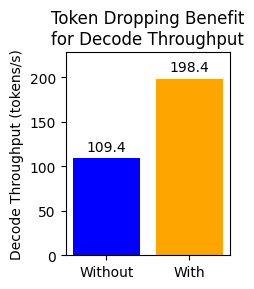

In [ ]:
labels = ["Without", "With"]
data = [
    before_drop_data["metrics"]["results"]["output_tput"],
    after_drop_data["metrics"]["results"]["output_tput"],
]

fig, ax = plt.subplots(figsize=(2.5, 3))
bars = ax.bar(labels, data, color=["blue", "orange"])
ax.bar_label(bars, fmt="%.1f", padding=3)
ax.set_ylabel("Decode Throughput (tokens/s)")
ax.set_title("Token Dropping Benefit\nfor Decode Throughput")
ax.margins(y=0.15)
plt.tight_layout()
plt.show()

## Close both contexts

In [ ]:
# Only close the context when done.
ctx.close()
qctx.close()

## Print the PID of both LMCache and vLLM processes, then kill them

In [ ]:
!pgrep -af "[l]mcache server" || echo "LMCache: NOT running"
!pgrep -af "[v]llm serve"     || echo "vLLM:    NOT running"

3369 /usr/bin/python3 /usr/local/bin/lmcache server --l1-size-gb 3 --eviction-policy LRU --chunk-size 256 --port 6555 --http-port 8081 --shm-name lmcache_sdk --no-l1-use-lazy --enable transfer_query --max-workers 4 --eviction-trigger-watermark 0.98
3490 /usr/bin/python3 /usr/local/bin/vllm serve Qwen/Qwen3-1.7B --port 8000 --served-model-name Qwen/Qwen3-1.7B --no-enable-prefix-caching --enforce-eager --gpu-memory-utilization 0.35 --kv-transfer-config {"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true,"lmcache.mp.heartbeat_interval":30}} --trust-remote-code --return-tokens-as-token-ids --max-model-len 2048 --max-num-batched-tokens 12288 --attention-backend TRITON_ATTN


In [ ]:
%%bash
VLLM_PID=$(pgrep -f "[v]llm serve" | head -1)
LMC_PID=$(pgrep -f "[l]mcache server" | head -1)

for pid in "$VLLM_PID" "$LMC_PID"; do
    [ -z "$pid" ] && continue
    pgid=$(ps -o pgid= -p "$pid" | tr -d ' ')
    ps -o pid,pgid,cmd -p "$pid"
    kill -KILL -"$pgid"
done

# The L1 pool in /dev/shm outlives the server process, so release it explicitly.
# Otherwise the next run starts with a stale multi-GiB block in /dev/shm.
sleep 2
rm -f /dev/shm/lmcache* 2>/dev/null || true
echo "--- /dev/shm after cleanup ---"
ls -A /dev/shm | grep lmcache || echo "no lmcache pool left (good)"


    PID    PGID CMD
   3490    3490 /usr/bin/python3 /usr/local/bin/vllm serve Qwen/Qwen3-1.7B --port 8000 --served-model-name Qwen/Qwen3-1.7B --no-enable-prefix-caching --enforce-eager --gpu-memory-utilization 0.35 --kv-transfer-config {"kv_connector":"LMCacheMPConnector","kv_role":"kv_both","kv_connector_extra_config":{"lmcache.mp.port":6555,"lmcache.mp.transfer_intermediate_tensors":true,"lmcache.mp.heartbeat_interval":30}} --trust-remote-code --return-tokens-as-token-ids --max-model-len 2048 --max-num-batched-tokens 12288 --attention-backend TRITON_ATTN
    PID    PGID CMD
   3369    3369 /usr/bin/python3 /usr/local/bin/lmcache server --l1-size-gb 3 --eviction-policy LRU --chunk-size 256 --port 6555 --http-port 8081 --shm-name lmcache_sdk --no-l1-use-lazy --enable transfer_query --max-workers 4 --eviction-trigger-watermark 0.98
--- /dev/shm after cleanup ---
no lmcache pool left (good)


In [ ]:
!pgrep -af "[l]mcache server" || echo "LMCache: NOT running"
!pgrep -af "[v]llm serve"     || echo "vLLM:    NOT running"

LMCache: NOT running
vLLM:    NOT running
